In [5]:
import pandas as pd

In [6]:
data = pd.read_csv("../data/raw/ai4i2020.csv")

In [3]:
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
data.shape

(10000, 14)

In [5]:
data.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [6]:
data.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [7]:
data.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [10]:
data["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

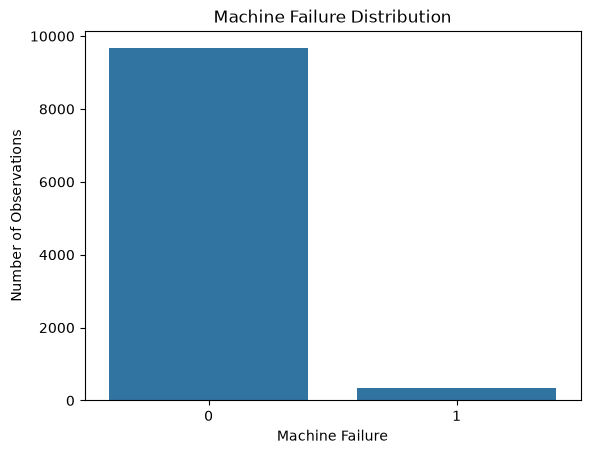

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Machine failure", data=data)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Observations")

plt.show()

In [12]:
data.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [13]:
data["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [14]:
data["Product ID"].nunique()

10000

In [15]:
data[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [16]:
pd.crosstab(data["Machine failure"], data["TWF"])

TWF,0,1
Machine failure,,
0,9661,0
1,293,46


In [17]:
pd.crosstab(data["Machine failure"], data["HDF"])

HDF,0,1
Machine failure,,
0,9661,0
1,224,115


In [18]:
pd.crosstab(data["Machine failure"], data["PWF"])

PWF,0,1
Machine failure,,
0,9661,0
1,244,95


In [19]:
pd.crosstab(data["Machine failure"], data["OSF"])

OSF,0,1
Machine failure,,
0,9661,0
1,241,98


In [20]:
pd.crosstab(data["Machine failure"], data["RNF"])

RNF,0,1
Machine failure,,
0,9643,18
1,338,1


In [21]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

target = "Machine failure"

In [22]:
X = data[features]

In [23]:
y = data[target]

In [24]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [25]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64

In [26]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 6)
y shape: (10000,)


In [27]:
X["Type"].unique()

<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 6)
X_test : (2000, 6)
y_train: (8000,)
y_test : (2000,)


In [31]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

Testing distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


In [32]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [34]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()

In [37]:
from sklearn.compose import ColumnTransformer

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaler, numerical_features),
        ("cat", encoder, categorical_features)
    ]
)

In [39]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [40]:
X_train_processed = preprocessor.transform(X_train)

In [41]:
X_test_processed = preprocessor.transform(X_test)

In [42]:
print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)

X_train shape: (8000, 8)
X_test shape: (2000, 8)


In [43]:
print(X_train_processed[:5])

[[ 0.99891359  0.60428162 -0.46060741  0.71830476 -0.84399726  0.
   0.          1.        ]
 [-1.50519408 -1.15325984 -0.77557391  0.63845583  0.38226308  0.
   0.          1.        ]
 [ 0.49809206  1.07746586 -1.00765448  0.5586069   0.46086951  0.
   0.          1.        ]
 [-0.55363316 -0.13929361 -0.70926517  1.62658635 -0.37235867  0.
   1.          0.        ]
 [-1.45511192 -1.01806434  1.07001923 -1.12820177 -0.90688241  0.
   1.          0.        ]]


In [44]:
X_train_processed = pd.DataFrame(X_train_processed)

X_train_processed.head()

,0,1,2,3,4,5,6,7
0,0.998914,0.604282,-0.460607,0.718305,-0.843997,0.0,0.0,1.0
1,-1.505194,-1.153260,-0.775574,0.638456,0.382263,0.0,0.0,1.0
2,0.498092,1.077466,-1.007654,0.558607,0.460870,0.0,0.0,1.0
3,-0.553633,-0.139294,-0.709265,1.626586,-0.372359,0.0,1.0,0.0
4,-1.455112,-1.018064,1.070019,-1.128202,-0.906882,0.0,1.0,0.0


In [45]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__Air temperature [K]' 'num__Process temperature [K]'
 'num__Rotational speed [rpm]' 'num__Torque [Nm]' 'num__Tool wear [min]'
 'cat__Type_H' 'cat__Type_L' 'cat__Type_M']


In [46]:
X_train_processed.columns = feature_names

X_train_processed.head()

,num__Air temperature [K],num__Process temperature [K],num__Rotational speed [rpm],num__Torque [Nm],num__Tool wear [min],cat__Type_H,cat__Type_L,cat__Type_M
0,0.998914,0.604282,-0.460607,0.718305,-0.843997,0.0,0.0,1.0
1,-1.505194,-1.153260,-0.775574,0.638456,0.382263,0.0,0.0,1.0
2,0.498092,1.077466,-1.007654,0.558607,0.460870,0.0,0.0,1.0
3,-0.553633,-0.139294,-0.709265,1.626586,-0.372359,0.0,1.0,0.0
4,-1.455112,-1.018064,1.070019,-1.128202,-0.906882,0.0,1.0,0.0


In [47]:
X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

X_test_processed.head()

,num__Air temperature [K],num__Process temperature [K],num__Rotational speed [rpm],num__Torque [Nm],num__Tool wear [min],cat__Type_H,cat__Type_L,cat__Type_M
0,0.247681,-0.139294,-1.073963,2.265378,0.712410,0.0,1.0,0.0
1,1.850310,1.618248,-0.145641,0.009646,0.429427,0.0,1.0,0.0
2,1.249324,0.942270,0.108543,-0.239882,1.592802,0.0,1.0,0.0
3,-2.206344,-2.505215,-0.167744,-0.419543,-0.749670,1.0,0.0,0.0
4,0.247681,-0.004098,-1.002129,2.035812,-0.089376,1.0,0.0,0.0


In [48]:
data.groupby("Machine failure")[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [49]:
data.groupby("Machine failure")["Tool wear [min]"].mean()

Machine failure
0    106.693717
1    143.781711
Name: Tool wear [min], dtype: float64

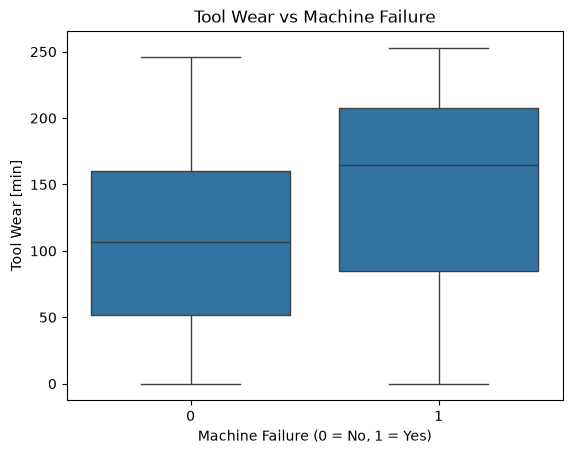

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="Machine failure",
    y="Tool wear [min]",
    data=data
)

plt.title("Tool Wear vs Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Tool Wear [min]")
plt.show()

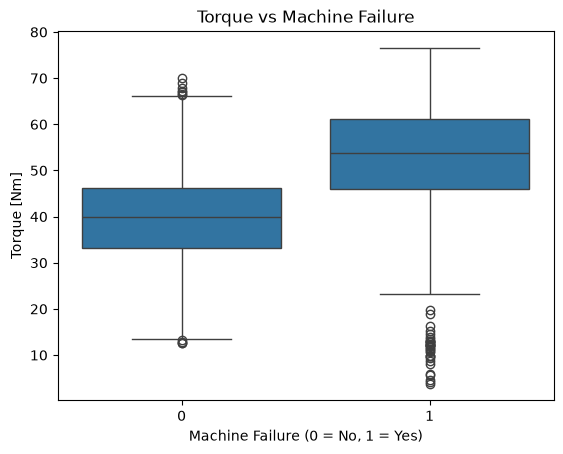

In [51]:
sns.boxplot(
    x="Machine failure",
    y="Torque [Nm]",
    data=data
)

plt.title("Torque vs Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Torque [Nm]")
plt.show()

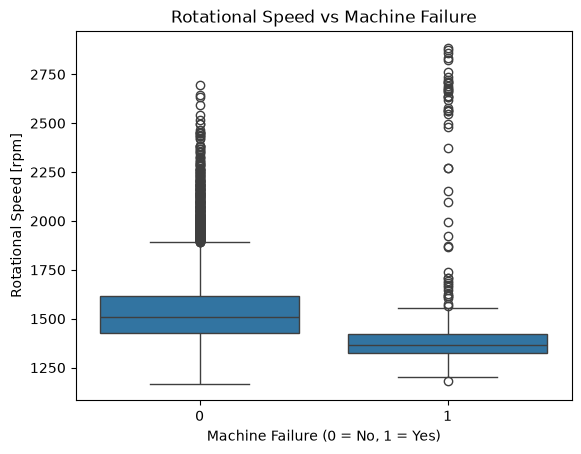

In [52]:
sns.boxplot(
    x="Machine failure",
    y="Rotational speed [rpm]",
    data=data
)

plt.title("Rotational Speed vs Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Rotational Speed [rpm]")
plt.show()

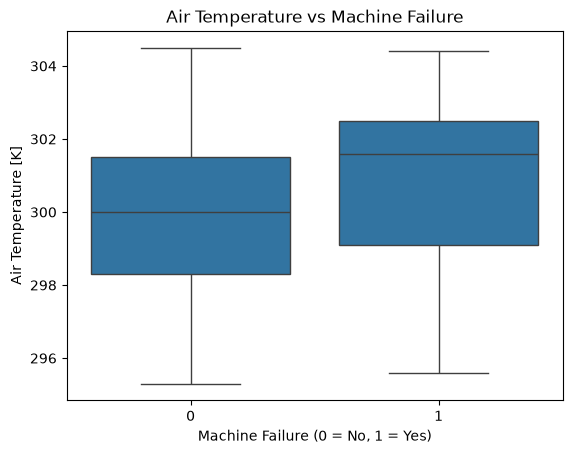

In [53]:
sns.boxplot(
    x="Machine failure",
    y="Air temperature [K]",
    data=data
)

plt.title("Air Temperature vs Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Air Temperature [K]")
plt.show()

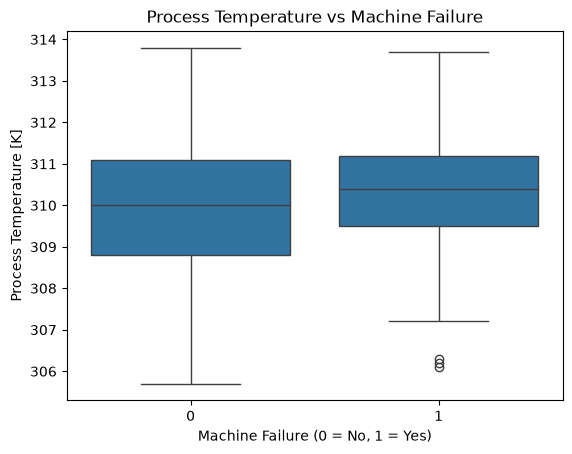

In [54]:
sns.boxplot(
    x="Machine failure",
    y="Process temperature [K]",
    data=data
)

plt.title("Process Temperature vs Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Process Temperature [K]")
plt.show()

In [55]:
pd.crosstab(
    data["Type"],
    data["Machine failure"]
)

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [56]:
data.groupby("Type")["Machine failure"].mean() * 100

Type
H    2.093719
L    3.916667
M    2.769436
Name: Machine failure, dtype: float64

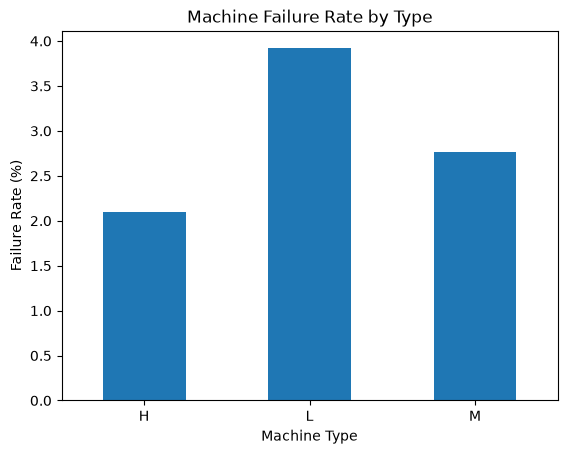

In [57]:
failure_rate = data.groupby("Type")["Machine failure"].mean() * 100

failure_rate.plot(kind="bar")

plt.title("Machine Failure Rate by Type")
plt.xlabel("Machine Type")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [58]:
numerical_data = data[numerical_features + ["Machine failure"]]

correlation = numerical_data.corr()

correlation

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


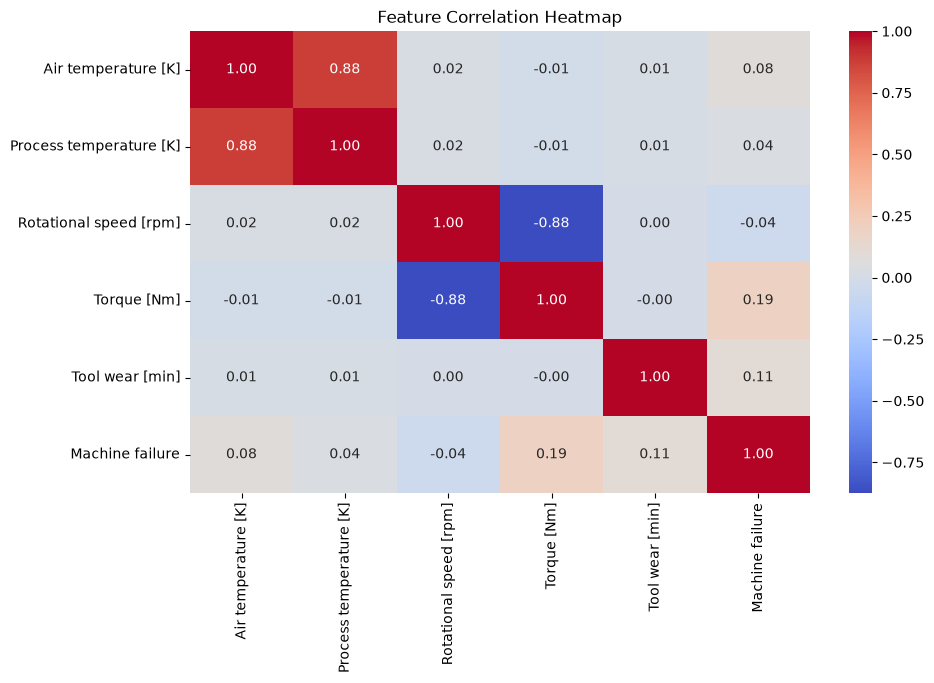

In [59]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

## EDA Summary

- The dataset contains 10,000 machine records.
- Machine failure is highly imbalanced: 96.61% normal and 3.39% failed.
- Failed machines generally show higher torque and tool wear.
- Failed machines generally show lower rotational speed.
- Air temperature and process temperature are slightly higher for failed machines.
- Machine type L has the highest observed failure rate among the three types.
- Air temperature and process temperature have a strong positive correlation.
- Rotational speed and torque have a strong negative correlation.
- Individual feature correlations with machine failure are relatively weak, suggesting that machine failure may depend on combinations and non-linear relationships between features.

In [60]:
from sklearn.linear_model import LogisticRegression


In [61]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [62]:
logistic_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [63]:
y_pred = logistic_model.predict(X_test_processed)

In [64]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9675


In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1928    4]
 [  61    7]]


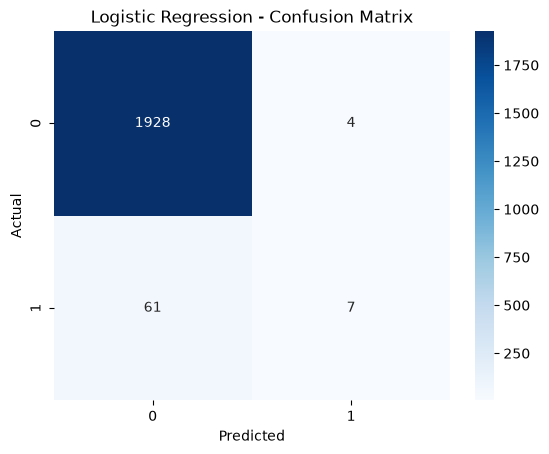

In [67]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [68]:
failure_recall = cm[1, 1] / (cm[1, 0] + cm[1, 1])

print("Failure Recall:", failure_recall)
print("Failure Recall (%):", failure_recall * 100)

Failure Recall: 0.10294117647058823
Failure Recall (%): 10.294117647058822


In [69]:
logistic_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

In [70]:
logistic_balanced.fit(X_train_processed, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [71]:
y_pred_balanced = logistic_balanced.predict(X_test_processed)

In [72]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



In [73]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print(cm_balanced)

[[1593  339]
 [  12   56]]


In [74]:
from sklearn.metrics import roc_auc_score

y_prob_balanced = logistic_balanced.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_balanced)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9069540859822189


In [75]:
from sklearn.ensemble import RandomForestClassifier

In [76]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [77]:
rf_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [78]:
y_pred_rf = rf_model.predict(X_test_processed)

In [79]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.72      0.65      0.68        68

    accuracy                           0.98      2000
   macro avg       0.85      0.82      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [80]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[1915   17]
 [  24   44]]


In [81]:
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.9611991535744733


In [84]:
from xgboost import XGBClassifier

In [85]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

In [87]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [88]:
print(X_train_processed.dtypes)

num__Air temperature [K]        float64
num__Process temperature [K]    float64
num__Rotational speed [rpm]     float64
num__Torque [Nm]                float64
num__Tool wear [min]            float64
cat__Type_H                     float64
cat__Type_L                     float64
cat__Type_M                     float64
dtype: object


In [89]:
X_train_xgb = X_train_processed.to_numpy()

In [90]:
X_test_xgb = X_test_processed.to_numpy()

In [91]:
xgb_model.fit(X_train_xgb, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [92]:
y_pred_xgb = xgb_model.predict(X_test_xgb)

In [93]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.69      0.78        68

    accuracy                           0.99      2000
   macro avg       0.94      0.84      0.88      2000
weighted avg       0.99      0.99      0.99      2000



In [94]:
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost ROC-AUC:", roc_auc_xgb)

XGBoost ROC-AUC: 0.9764644988430154


In [96]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [97]:
y_train_ann = y_train.to_numpy()
y_test_ann = y_test.to_numpy()

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [99]:
ann_model = Sequential([
    Dense(16, activation="relu", input_shape=(8,)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

d:\PredictX\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [100]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

ann_model = Sequential([
    Input(shape=(8,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [101]:
ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [102]:
ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
history = ann_model.fit(
    X_train_processed,
    y_train_ann,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9034 - loss: 0.3457 - val_accuracy: 0.9656 - val_loss: 0.1624
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9663 - loss: 0.1416 - val_accuracy: 0.9656 - val_loss: 0.1278
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9663 - loss: 0.1173 - val_accuracy: 0.9675 - val_loss: 0.1126
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - accuracy: 0.9698 - loss: 0.1046 - val_accuracy: 0.9694 - val_loss: 0.1060
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9705 - loss: 0.0984 - val_accuracy: 0.9681 - val_loss: 0.1031
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9719 - loss: 0.0943 - val_accuracy: 0.9688 - val_loss: 0.0994
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9730 - loss: 0.0910 - val_accuracy: 0.9688 - val_loss: 0.0986
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9731 - loss: 0.0882 - val_accuracy: 

In [104]:
print("Training completed!")
print("Epochs completed:", len(history.history["loss"]))

Training completed!
Epochs completed: 30


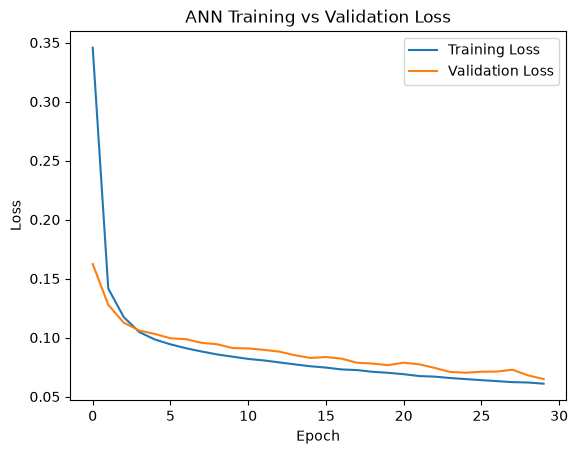

In [105]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("ANN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [106]:
y_prob_ann = ann_model.predict(
    X_test_processed,
    verbose=0
).ravel()

print(y_prob_ann[:10])

[4.4522402e-01 4.4902340e-03 5.7533603e-02 4.7802252e-05 5.3474359e-02
 1.3092299e-02 2.2910382e-01 5.3067540e-04 1.2348921e-04 2.9103644e-02]


In [107]:
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

print(y_pred_ann[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [108]:
print(classification_report(y_test_ann, y_pred_ann))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1932
           1       0.74      0.47      0.58        68

    accuracy                           0.98      2000
   macro avg       0.86      0.73      0.78      2000
weighted avg       0.97      0.98      0.97      2000



In [109]:
roc_auc_ann = roc_auc_score(y_test_ann, y_prob_ann)

print("ANN ROC-AUC:", roc_auc_ann)

ANN ROC-AUC: 0.9646434660820851


In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "XGBoost",
        "ANN"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test_ann, y_pred_ann)
    ],
    "Failure Recall": [
        classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_balanced, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_xgb, output_dict=True)["1"]["recall"],
        classification_report(y_test_ann, y_pred_ann, output_dict=True)["1"]["recall"]
    ],
    "Failure F1": [
        classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_balanced, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_xgb, output_dict=True)["1"]["f1-score"],
        classification_report(y_test_ann, y_pred_ann, output_dict=True)["1"]["f1-score"]
    ],
    "ROC-AUC": [
        None,
        roc_auc,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_ann
    
})

model_results

,Model,Accuracy,Failure Recall,Failure F1,ROC-AUC
0,Logistic Regression,0.9675,0.102941,0.177215,NaN
1,Balanced Logistic Regression,0.8245,0.823529,0.241901,0.906954
2,Random Forest,0.9795,0.647059,0.682171,0.961199
3,XGBoost,0.9865,0.691176,0.776860,0.976464
4,ANN,0.9765,0.470588,0.576577,0.964643


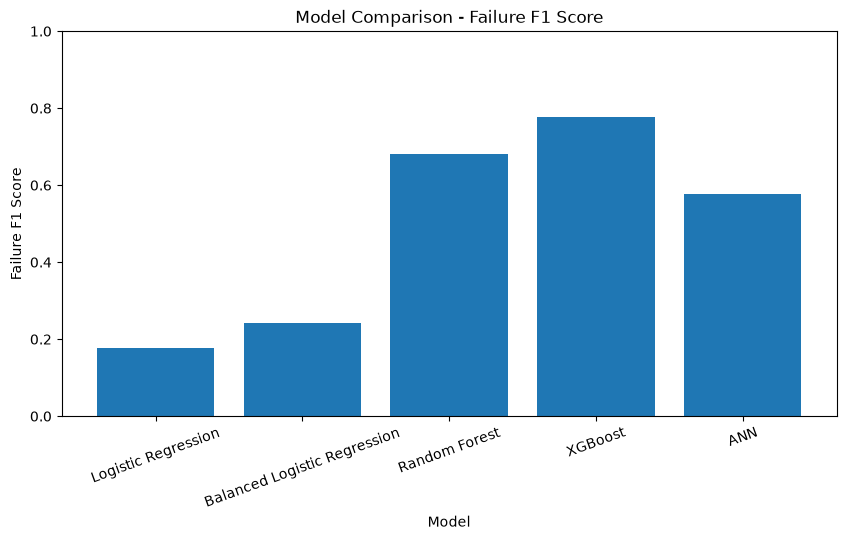

In [111]:
plt.figure(figsize=(10, 5))

plt.bar(
    model_results["Model"],
    model_results["Failure F1"]
)

plt.title("Model Comparison - Failure F1 Score")
plt.xlabel("Model")
plt.ylabel("Failure F1 Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

In [112]:
print(y_prob_xgb[:20])

[0.11000389 0.0006176  0.06828775 0.00088285 0.01505032 0.00077276
 0.03500282 0.00083862 0.00023347 0.03962386 0.00037085 0.0017327
 0.0008175  0.00155181 0.00139251 0.00072415 0.0007199  0.08170927
 0.00093797 0.00086915]


In [113]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:
    predictions = (y_prob_xgb >= threshold).astype(int)
    
    recall = classification_report(
        y_test,
        predictions,
        output_dict=True
    )["1"]["recall"]
    
    precision = classification_report(
        y_test,
        predictions,
        output_dict=True
    )["1"]["precision"]
    
    f1 = classification_report(
        y_test,
        predictions,
        output_dict=True
    )["1"]["f1-score"]
    
    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.1 | Precision: 0.56 | Recall: 0.82 | F1: 0.67
Threshold: 0.2 | Precision: 0.72 | Recall: 0.82 | F1: 0.77
Threshold: 0.3 | Precision: 0.82 | Recall: 0.78 | F1: 0.80
Threshold: 0.4 | Precision: 0.86 | Recall: 0.74 | F1: 0.79
Threshold: 0.5 | Precision: 0.89 | Recall: 0.69 | F1: 0.78


In [114]:
xgb_threshold = 0.30

y_pred_xgb_tuned = (y_prob_xgb >= xgb_threshold).astype(int)

print(y_pred_xgb_tuned[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [115]:
print(classification_report(y_test, y_pred_xgb_tuned))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.82      0.78      0.80        68

    accuracy                           0.99      2000
   macro avg       0.90      0.89      0.90      2000
weighted avg       0.99      0.99      0.99      2000



In [116]:
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

print(cm_xgb_tuned)

[[1920   12]
 [  15   53]]


In [117]:
FINAL_THRESHOLD = 0.30

print("Final XGBoost threshold:", FINAL_THRESHOLD)

Final XGBoost threshold: 0.3


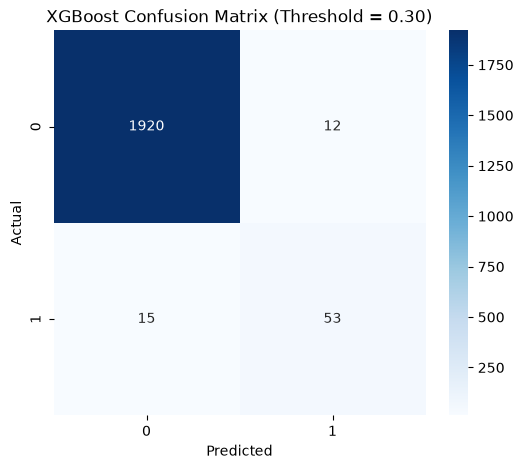

In [118]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb_tuned,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix (Threshold = 0.30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [119]:
import joblib

In [120]:
joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [121]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [122]:
import json

with open("../models/config.json", "w") as file:
    json.dump({"threshold": FINAL_THRESHOLD}, file)

print("Threshold saved successfully!")

Threshold saved successfully!


In [2]:
import joblib

xgb_model = joblib.load("../models/xgboost_model.pkl")

print("XGBoost model loaded successfully!")

XGBoost model loaded successfully!


In [3]:
feature_importance = xgb_model.feature_importances_

print(feature_importance)

[0.14790674 0.08623904 0.18965895 0.26598275 0.15751189 0.04317238
 0.03993567 0.06959254]


In [7]:
feature_names = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type_H",
    "Type_L",
    "Type_M"
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df

,Feature,Importance
0,Air temperature [K],0.147907
1,Process temperature [K],0.086239
2,Rotational speed [rpm],0.189659
3,Torque [Nm],0.265983
4,Tool wear [min],0.157512
5,Type_H,0.043172
6,Type_L,0.039936
7,Type_M,0.069593


In [8]:
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df

,Feature,Importance
3,Torque [Nm],0.265983
2,Rotational speed [rpm],0.189659
4,Tool wear [min],0.157512
0,Air temperature [K],0.147907
1,Process temperature [K],0.086239
7,Type_M,0.069593
5,Type_H,0.043172
6,Type_L,0.039936


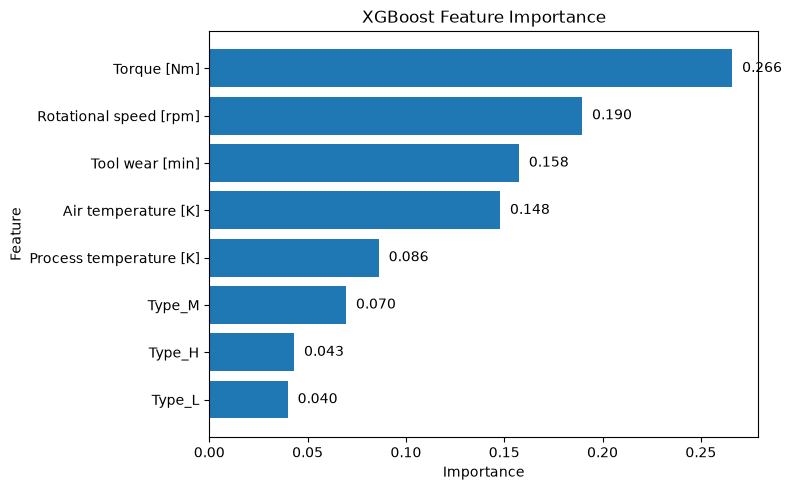

In [11]:
plt.figure(figsize=(8, 5))

bars = plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

for bar, value in zip(bars, importance_df["Importance"]):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.savefig("../models/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()